# Toward error vs. SNR: first working slice

**Goal:** plot **pulse reconstruction error vs. trace SNR** (test set, after training).

**This notebook:** supervised **train + validation + test** on simulated FROG traces.

- **Model:** imported from an **external module** (not defined here).
- **Noise on traces:** injected via an **external callable** (default: `trace_noise.py`; you can swap it).
- **Forward physics:** `FROGNet` from `frognet.py`.

Training uses random SNR per batch; validation uses a fixed `VAL_SNR_DB` and plots L1 vs. epoch. After training: SNR sweep on **test** and error-vs-SNR plot.

**Code cell below:**
- Imports (PyTorch, plotting, data loaders).
- External **model** (`TraceToPulseCNN`) and **noise** (`add_trace_noise` from `trace_noise`).
- Project helpers: pulse generation + `FROGNet`.

In [1]:
from __future__ import annotations

from typing import Callable

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from data_generation import generate_pulses_gaussian
from frognet import FROGNet

# --- External model (replace module/class as needed) ---
from frog_reconstruction_model import TraceToPulseCNN

# --- External trace noise (replace module/function as needed; not required to be utils.py) ---
from trace_noise import add_trace_noise_awgn

add_trace_noise: Callable[[torch.Tensor, float], torch.Tensor] = add_trace_noise_awgn

**Code cell below:**
- `DEVICE`, random seed, grid size `N`.
- Dataset sizes (train / val / **test**), batch size, epochs, learning rate.
- Train SNR range, fixed validation SNR (`VAL_SNR_DB`), SNR sweep grid, checkpoint path.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

N = 64  # time samples; FROG trace [B, N, N] when num_delay_steps == N
N_TRAIN = 2048
N_VAL = 512
N_TEST = 512
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3

TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)  # -10, -5, 0, 5, ..., 30 dB
CHECKPOINT_PATH = "checkpoints/trace_to_pulse_cnn.pt"

PCGPA_MAXITER = 200
PCGPA_N_RESTARTS = 3
PCGPA_N_TEST = 32  # set to N_TEST for full PCGPA sweep

print("DEVICE:", DEVICE)

DEVICE: cpu


**Code cell below:**
- Generate synthetic pulses; pack to `[B, 2N]`.
- Forward through `FROGNet` → clean traces `I_train`, `I_val`, `I_test`.
- Build train / val / **test** `DataLoader`s (noise added later in the loop).

In [3]:
def pack_pulses_complex(pulses_c: np.ndarray) -> torch.Tensor:
    """[B, N] complex -> [B, 2N] float32 (Re then Im)."""
    r = np.real(pulses_c).astype(np.float32)
    im = np.imag(pulses_c).astype(np.float32)
    return torch.from_numpy(np.concatenate([r, im], axis=-1))


p_train_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_TRAIN,
    dt=1.0,
    sigma_omega=0.35,
    num_points=N,
    seed=SEED,
)
p_val_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_VAL,
    dt=1.0,
    sigma_omega=0.35,
    num_points=N,
    seed=SEED + 1,
)
p_test_c, _, _, _ = generate_pulses_gaussian(
    n_pulses=N_TEST,
    dt=1.0,
    sigma_omega=0.35,
    num_points=N,
    seed=SEED + 2,
)

E_train = pack_pulses_complex(p_train_c).to(DEVICE)
E_val = pack_pulses_complex(p_val_c).to(DEVICE)
E_test = pack_pulses_complex(p_test_c).to(DEVICE)

frog = FROGNet(num_delay_steps=N).to(DEVICE)
frog.eval()

with torch.no_grad():
    I_train = frog(E_train)
    I_val = frog(E_val)
    I_test = frog(E_test)

train_loader = DataLoader(
    TensorDataset(I_train, E_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=False
)
val_loader = DataLoader(
    TensorDataset(I_val, E_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
test_loader = DataLoader(
    TensorDataset(I_test, E_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

print("E_train", tuple(E_train.shape), "I_train", tuple(I_train.shape))
print("E_test", tuple(E_test.shape), "I_test", tuple(I_test.shape))

E_train (2048, 128) I_train (2048, 64, 64)
E_test (512, 128) I_test (512, 64, 64)


**Code cell below:**
- Instantiate imported `TraceToPulseCNN` on `DEVICE`.
- One dummy forward (for `LazyLinear`); print parameter count.

In [4]:
model = TraceToPulseCNN(out_dim=2 * N).to(DEVICE)
_ = model(I_train[:2].unsqueeze(1))
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 4266208


**Code cell below:**
- Train loop: random SNR → `add_trace_noise` → model → L1 loss → Adam.
- Val loop each epoch: fixed `VAL_SNR_DB`, mean L1 on val set.
- Print train/val loss per epoch; store curves in lists.

In [5]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses: list[float] = []
val_l1_pulses: list[float] = []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    n_seen = 0
    for I_clean, E_true in train_loader:
        snr = float(np.random.uniform(TRAIN_SNR_DB_RANGE[0], TRAIN_SNR_DB_RANGE[1]))
        I_noisy = add_trace_noise(I_clean, snr)
        x = I_noisy.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        E_pred = model(x)
        loss = criterion(E_pred, E_true)
        loss.backward()
        optimizer.step()

        b = I_clean.shape[0]
        running += loss.item() * b
        n_seen += b

    train_losses.append(running / max(n_seen, 1))

    model.eval()
    vsum, vcount = 0.0, 0
    with torch.no_grad():
        for I_clean, E_true in val_loader:
            I_noisy = add_trace_noise(I_clean, VAL_SNR_DB)
            E_pred = model(I_noisy.unsqueeze(1))
            vloss = criterion(E_pred, E_true)
            b = I_clean.shape[0]
            vsum += vloss.item() * b
            vcount += b
    val_l1_pulses.append(vsum / max(vcount, 1))

    print(
        f"epoch {epoch+1:03d}/{EPOCHS}  train_L1={train_losses[-1]:.5f}  "
        f"val_L1@{VAL_SNR_DB:.1f}dB={val_l1_pulses[-1]:.5f}"
    )

print("Done.")

epoch 001/15  train_L1=0.04742  val_L1@15.0dB=0.03974
epoch 002/15  train_L1=0.03982  val_L1@15.0dB=0.03906
epoch 003/15  train_L1=0.03887  val_L1@15.0dB=0.03751
epoch 004/15  train_L1=0.03627  val_L1@15.0dB=0.03429
epoch 005/15  train_L1=0.03437  val_L1@15.0dB=0.03343
epoch 006/15  train_L1=0.03353  val_L1@15.0dB=0.03264
epoch 007/15  train_L1=0.03287  val_L1@15.0dB=0.03220
epoch 008/15  train_L1=0.03217  val_L1@15.0dB=0.03169
epoch 009/15  train_L1=0.03168  val_L1@15.0dB=0.03136
epoch 010/15  train_L1=0.03123  val_L1@15.0dB=0.03107
epoch 011/15  train_L1=0.03097  val_L1@15.0dB=0.03126
epoch 012/15  train_L1=0.03060  val_L1@15.0dB=0.03072
epoch 013/15  train_L1=0.03049  val_L1@15.0dB=0.03064
epoch 014/15  train_L1=0.03015  val_L1@15.0dB=0.03028
epoch 015/15  train_L1=0.02975  val_L1@15.0dB=0.03016
Done.


**Code cell below:**
- Plot **train** and **val** mean L1 vs. epoch on the **same axes**.
- Legend + grid; `plt.show()`.

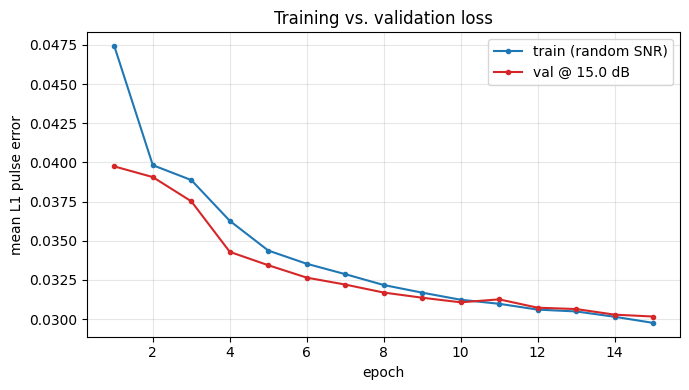

In [6]:
epochs_axis = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_axis, train_losses, "-o", markersize=3, label="train (random SNR)")
plt.plot(
    epochs_axis,
    val_l1_pulses,
    "-o",
    color="tab:red",
    markersize=3,
    label=f"val @ {VAL_SNR_DB:.1f} dB",
)
plt.xlabel("epoch")
plt.ylabel("mean L1 pulse error")
plt.title("Training vs. validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Code cell below** (run after training — do not re-run the train cell):

- `l1_stats_at_snr` — per test pulse: fixed-SNR noise → predict → L1; return **mean ± std** over pulses.
- Save model weights to `CHECKPOINT_PATH`.
- Loop over `SNR_SWEEP_DB` (−10…30 dB); print mean ± std at each SNR.
- Plot: X = trace SNR (dB), Y = mean L1 with **error bars** (±1 std over test pulses).

Saved: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\checkpoints\trace_to_pulse_cnn.pt
test L1 @ -10.0 dB = 0.03982 ± 0.01052
test L1 @ -5.0 dB = 0.03388 ± 0.01226
test L1 @ 0.0 dB = 0.03103 ± 0.01313
test L1 @ 5.0 dB = 0.03001 ± 0.01360
test L1 @ 10.0 dB = 0.02968 ± 0.01378
test L1 @ 15.0 dB = 0.02957 ± 0.01387
test L1 @ 20.0 dB = 0.02954 ± 0.01391
test L1 @ 25.0 dB = 0.02953 ± 0.01391
test L1 @ 30.0 dB = 0.02952 ± 0.01394


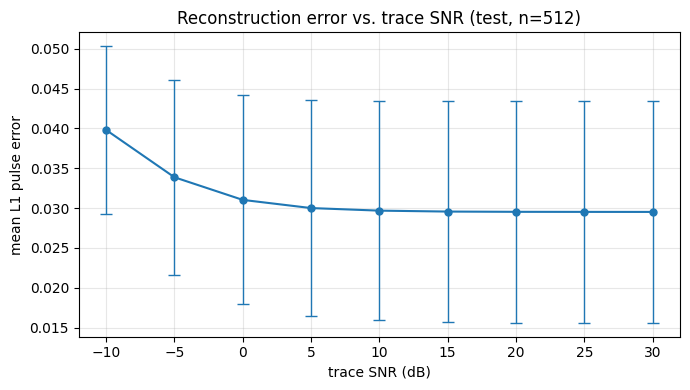

In [7]:
from pathlib import Path


def l1_stats_at_snr(loader: DataLoader, snr_db: float) -> tuple[float, float]:
    """Mean and std of per-pulse L1 (mean |error| over Re/Im samples)."""
    model.eval()
    per_pulse: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            l1 = (E_pred - E_true).abs().mean(dim=1)
            per_pulse.extend(l1.cpu().tolist())
    arr = np.asarray(per_pulse, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


ckpt_path = Path(CHECKPOINT_PATH)
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "N": N,
        "train_snr_db_range": TRAIN_SNR_DB_RANGE,
    },
    ckpt_path,
)
print("Saved:", ckpt_path.resolve())

test_l1_mean: list[float] = []
test_l1_std: list[float] = []
for snr_db in SNR_SWEEP_DB:
    mean_err, std_err = l1_stats_at_snr(test_loader, float(snr_db))
    test_l1_mean.append(mean_err)
    test_l1_std.append(std_err)
    print(f"test L1 @ {snr_db:.1f} dB = {mean_err:.5f} ± {std_err:.5f}")

plt.figure(figsize=(7, 4))
plt.errorbar(
    SNR_SWEEP_DB,
    test_l1_mean,
    yerr=test_l1_std,
    fmt="-o",
    markersize=5,
    capsize=4,
    elinewidth=1,
)
plt.xlabel("trace SNR (dB)")
plt.ylabel("mean L1 pulse error")
plt.title(f"Reconstruction error vs. trace SNR (test, n={N_TEST})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
model

TraceToPulseCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (5): ReLU(inplace=True)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=8192, out_features=512, bias=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=512, out_features=128, bias=True)
  )
)

## PCGPA baseline (classical)

`pcgpa_reconstruct.py` runs PCGPA on the **same** FROGNet traces `[N_ω, N_τ]` (random initial guess; no ground-truth spectrum). SNR sweep: **four** plots. **PCGPA** always uses `best_delta_e_ambiguity` / `best_l1_ambiguity` on the recovered pulse. **CNN** is compared with vs. without those helpers: (1) δE CNN raw + PCGPA amb., (2) δE both amb., (3)–(4) same for L1. Printed `max |CNN raw − amb|` tests if ambiguity search matters for the CNN.

Requires:
- `vendor/pypret`: `git clone --depth 1 https://github.com/ncgeib/pypret.git vendor/pypret`
- Python packages (in your notebook venv): `pip install h5py scipy`

**Run all cells above first** (imports → hyperparameters → data/`I_test` → model → training or load checkpoint). PCGPA cells use `I_test`, `E_test`, `SEED`, `PCGPA_MAXITER`, `add_trace_noise`.

In [9]:
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pcgpa_reconstruct

pcgpa_reconstruct = pcgpa_reconstruct.reload_from_disk()
print("pcgpa_reconstruct:", pcgpa_reconstruct.__file__)
best_delta_e_ambiguity = pcgpa_reconstruct.best_delta_e_ambiguity
reconstruct_pcgpa = pcgpa_reconstruct.reconstruct_pcgpa
unpack_packed_field = pcgpa_reconstruct.unpack_packed_field

_pcgpa_prereq = ("I_test", "E_test", "SEED", "PCGPA_MAXITER", "add_trace_noise")
_missing = [n for n in _pcgpa_prereq if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run earlier notebook cells first (data + hyperparameters). Missing: "
        + ", ".join(_missing)
    )

# --- smoke test: one test pulse, clean trace ---
_i = 0
_i_clean = I_test[_i].cpu().numpy()
_e_ref = unpack_packed_field(E_test[_i].cpu().numpy())
_e_pcgpa = reconstruct_pcgpa(
    _i_clean,
    maxiter=PCGPA_MAXITER,
    rng=np.random.default_rng(SEED),
)
print(
    "PCGPA smoke (clean trace), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa, _e_ref):.6f} rad",
)

_i_noisy = add_trace_noise(I_test[_i : _i + 1], 10.0).squeeze(0).cpu().numpy()
_e_pcgpa_noisy = reconstruct_pcgpa(
    _i_noisy,
    maxiter=PCGPA_MAXITER,
    rng=np.random.default_rng(SEED + 1),
)
print(
    "PCGPA smoke (10 dB), best δE:",
    f"{best_delta_e_ambiguity(_e_pcgpa_noisy, _e_ref):.6f} rad",
)

pcgpa_reconstruct: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\pcgpa_reconstruct.py
PCGPA smoke (clean trace), best δE: 0.707409 rad
PCGPA smoke (10 dB), best δE: 0.751282 rad


Sweep — PCGPA n=32 (always best amb.), CNN n=512 (raw vs best amb.)
CNN δE: max |mean(raw) − mean(amb)| over SNR = 0.148701 rad
CNN L1: max |mean(raw) − mean(amb)| over SNR = 0.004674


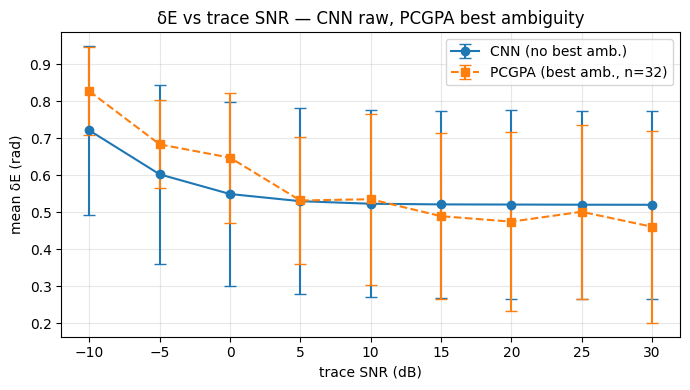

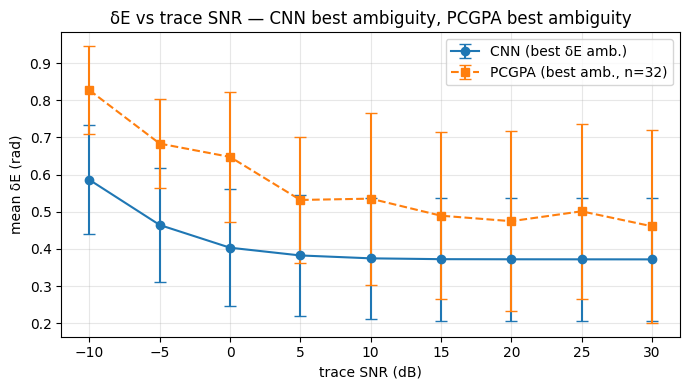

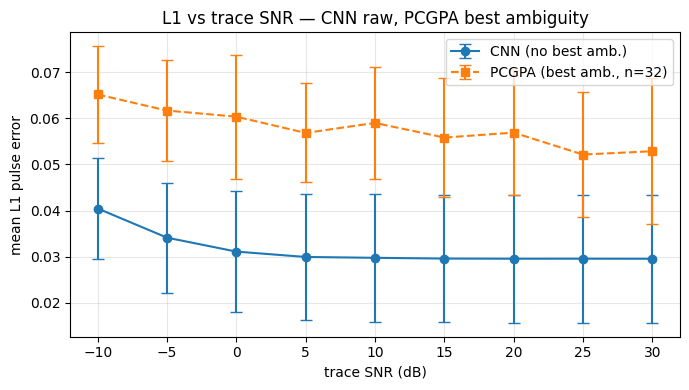

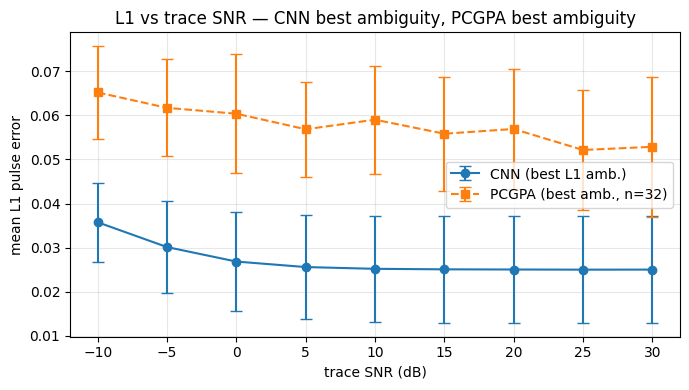

In [10]:
def _packed_batch_to_complex(E_packed: torch.Tensor) -> np.ndarray:
    half = E_packed.shape[-1] // 2
    x = E_packed.detach().cpu().numpy()
    return x[..., :half] + 1j * x[..., half:]


def mean_delta_e_cnn_at_snr(
    loader: DataLoader, snr_db: float, *, score_fn
) -> tuple[float, float]:
    model.eval()
    per: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            rec = _packed_batch_to_complex(E_pred)
            true = _packed_batch_to_complex(E_true)
            for i in range(rec.shape[0]):
                per.append(float(score_fn(rec[i], true[i])))
    arr = np.asarray(per, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


def mean_l1_cnn_at_snr(
    loader: DataLoader, snr_db: float, *, score_fn, truth: str = "complex"
) -> tuple[float, float]:
    model.eval()
    per: list[float] = []
    with torch.no_grad():
        for I_clean, E_true in loader:
            I_noisy = add_trace_noise(I_clean, snr_db)
            E_pred = model(I_noisy.unsqueeze(1))
            rec = _packed_batch_to_complex(E_pred)
            true_c = _packed_batch_to_complex(E_true)
            for i in range(rec.shape[0]):
                ref = (
                    E_true[i].cpu().numpy()
                    if truth == "packed"
                    else true_c[i]
                )
                per.append(float(score_fn(rec[i], ref)))
    arr = np.asarray(per, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=0))


import pcgpa_reconstruct

_pcgpa = pcgpa_reconstruct.reload_from_disk()
mean_delta_e_at_snr_pcgpa = _pcgpa.mean_delta_e_at_snr_pcgpa
mean_l1_at_snr_pcgpa = _pcgpa.mean_l1_at_snr_pcgpa
best_delta_e_ambiguity = _pcgpa.best_delta_e_ambiguity
best_l1_ambiguity = _pcgpa.best_l1_ambiguity
delta_e_numpy = _pcgpa.delta_e_numpy
l1_packed_mae = _pcgpa.l1_packed_mae
if getattr(_pcgpa, "PCGPA_API_VERSION", 0) < 3:
    raise RuntimeError(
        f"Stale pcgpa at {_pcgpa.__file__} (API v{getattr(_pcgpa, 'PCGPA_API_VERSION', '?')}); "
        "restart kernel and re-run smoke cell"
    )

_i_test_np = I_test.cpu().numpy()
_e_test_np = E_test.cpu().numpy()

_pcgpa_kw = dict(
    add_noise_fn=add_trace_noise,
    maxiter=PCGPA_MAXITER,
    n_subsample=PCGPA_N_TEST,
    n_restarts=PCGPA_N_RESTARTS,
    seed=SEED,
)


def _plot_snr_curves(
    snr_db,
    series: list[tuple[list[float], list[float], str, str]],
    *,
    ylabel: str,
    title: str,
) -> None:
    plt.figure(figsize=(7, 4))
    for mean, std, fmt, label in series:
        plt.errorbar(snr_db, mean, yerr=std, fmt=fmt, label=label, capsize=4)
    plt.xlabel("trace SNR (dB)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# PCGPA: always best ambiguity on recovered pulse. CNN: raw vs best ambiguity.
pcgpa_de_m, pcgpa_de_s = [], []
pcgpa_l1_m, pcgpa_l1_s = [], []
cnn_de_raw_m, cnn_de_raw_s = [], []
cnn_de_amb_m, cnn_de_amb_s = [], []
cnn_l1_raw_m, cnn_l1_raw_s = [], []
cnn_l1_amb_m, cnn_l1_amb_s = [], []

print(
    f"Sweep — PCGPA n={PCGPA_N_TEST} (always best amb.), "
    f"CNN n={N_TEST} (raw vs best amb.)"
)
for snr_db in SNR_SWEEP_DB:
    m, s = mean_delta_e_at_snr_pcgpa(
        _i_test_np, _e_test_np, float(snr_db), use_best_ambiguity=True, **_pcgpa_kw
    )
    pcgpa_de_m.append(m)
    pcgpa_de_s.append(s)
    m, s = mean_l1_at_snr_pcgpa(
        _i_test_np, _e_test_np, float(snr_db), use_best_ambiguity=True, **_pcgpa_kw
    )
    pcgpa_l1_m.append(m)
    pcgpa_l1_s.append(s)

    m, s = mean_delta_e_cnn_at_snr(
        test_loader, float(snr_db), score_fn=delta_e_numpy
    )
    cnn_de_raw_m.append(m)
    cnn_de_raw_s.append(s)
    m, s = mean_delta_e_cnn_at_snr(
        test_loader, float(snr_db), score_fn=best_delta_e_ambiguity
    )
    cnn_de_amb_m.append(m)
    cnn_de_amb_s.append(s)

    m, s = mean_l1_cnn_at_snr(
        test_loader,
        float(snr_db),
        score_fn=lambda rec, packed: l1_packed_mae(
            rec, packed, use_best_ambiguity=False
        ),
        truth="packed",
    )
    cnn_l1_raw_m.append(m)
    cnn_l1_raw_s.append(s)
    m, s = mean_l1_cnn_at_snr(
        test_loader, float(snr_db), score_fn=best_l1_ambiguity
    )
    cnn_l1_amb_m.append(m)
    cnn_l1_amb_s.append(s)

cnn_de_max_diff = max(abs(a - b) for a, b in zip(cnn_de_raw_m, cnn_de_amb_m))
cnn_l1_max_diff = max(abs(a - b) for a, b in zip(cnn_l1_raw_m, cnn_l1_amb_m))
print(f"CNN δE: max |mean(raw) − mean(amb)| over SNR = {cnn_de_max_diff:.6f} rad")
print(f"CNN L1: max |mean(raw) − mean(amb)| over SNR = {cnn_l1_max_diff:.6f}")

_pcgpa_lbl = f"PCGPA (best amb., n={PCGPA_N_TEST})"

# (1) δE: CNN without best amb. + PCGPA with best amb.
_plot_snr_curves(
    SNR_SWEEP_DB,
    [
        (cnn_de_raw_m, cnn_de_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_de_m, pcgpa_de_s, "--s", _pcgpa_lbl),
    ],
    ylabel="mean δE (rad)",
    title="δE vs trace SNR — CNN raw, PCGPA best ambiguity",
)

# (2) δE: CNN with best amb. + PCGPA with best amb.
_plot_snr_curves(
    SNR_SWEEP_DB,
    [
        (cnn_de_amb_m, cnn_de_amb_s, "-o", "CNN (best δE amb.)"),
        (pcgpa_de_m, pcgpa_de_s, "--s", _pcgpa_lbl),
    ],
    ylabel="mean δE (rad)",
    title="δE vs trace SNR — CNN best ambiguity, PCGPA best ambiguity",
)

# (3) L1: CNN without best amb. + PCGPA with best amb.
_plot_snr_curves(
    SNR_SWEEP_DB,
    [
        (cnn_l1_raw_m, cnn_l1_raw_s, "-o", "CNN (no best amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    ylabel="mean L1 pulse error",
    title="L1 vs trace SNR — CNN raw, PCGPA best ambiguity",
)

# (4) L1: CNN with best amb. + PCGPA with best amb.
_plot_snr_curves(
    SNR_SWEEP_DB,
    [
        (cnn_l1_amb_m, cnn_l1_amb_s, "-o", "CNN (best L1 amb.)"),
        (pcgpa_l1_m, pcgpa_l1_s, "--s", _pcgpa_lbl),
    ],
    ylabel="mean L1 pulse error",
    title="L1 vs trace SNR — CNN best ambiguity, PCGPA best ambiguity",
)